# L96 figures and animations

In [1]:
%load_ext autoreload
%autoreload 2

from L96 import *
import matplotlib.pyplot as plt
import numpy as np
from parametrizations import *
import torch
import os
import torch.nn as nn
from util import *
import pickle
import xarray as xr
import time
from scipy.special import rel_entr  # Import KL-divergence

### M hyper opt evaluation

In [4]:
import pandas as pd
pts, dzs, losses, preds = [], [], [], []
for file in os.listdir('hyper_opt/initial_pt_tests/offline_R2/'):
    if 'pkl' in file:
        model = torch.load('hyper_opt/initial_pt_tests/offline_R2/' + file, map_location='cpu', weights_only=False)
        pts.append(model.past_timesteps)
        dzs.append(model.latent_dims)
        losses.append(np.mean(model.R2[-1]))
        # preds.append(np.mean(model.nonlinear_predictability.detach().cpu().numpy()))

df = pd.DataFrame(np.array([pts, dzs, losses]).T, columns=['M', 'd_z', 'test loss'])
df = df.sort_values(['d_z', 'M'])
# Format the columns as requested
df['M'] = df['M'].astype(int)           # M as integer
df['d_z'] = df['d_z'].astype(int)       # d_z as integer
df['test loss'] = df['test loss'].map('{:.3f}'.format)  # 3 decimal places
#df['upper predictability boundary R^2'] = df['upper predictability boundary R^2'].map('{:.2f}'.format)  # 2 decimal places

df.to_latex('hyper_opt/initial_pt_tests/offline_R2/summary_latex_table', index=False)
df

,M,d_z,test loss
3,10,4,0.882
2,100,4,0.919
0,1000,4,0.931
4,10,8,0.882
1,100,8,0.919
5,1000,8,0.937


In [2]:
model10 = torch.load('hyper_opt/initial_pt_tests/m=0.001_tau=0.001_init_hyper_opt_pt=10_20260603131555.pkl', map_location='cpu', weights_only=False)
model100 = torch.load('hyper_opt/initial_pt_tests/m=0.001_tau=0.001_init_hyper_opt_pt=100_20260603131920.pkl', map_location='cpu', weights_only=False)
model1000 = torch.load('hyper_opt/initial_pt_tests/m=0.001_tau=0.001_init_hyper_opt_pt=1000_20260603132655.pkl', map_location='cpu', weights_only=False)

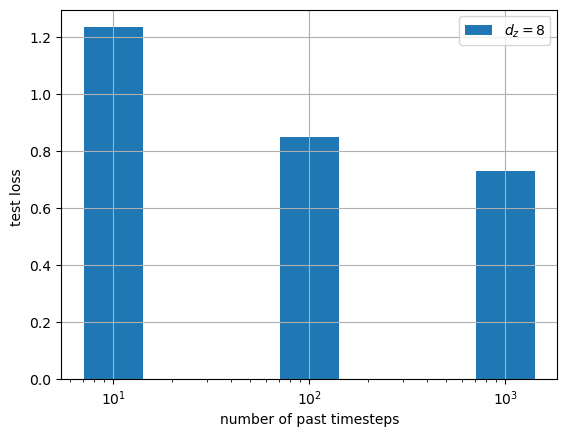

In [31]:
x, height = [], []

for model in [model10, model100, model1000]:
    x.append(model.past_timesteps)
    height.append(min(model.test_loss))

plt.xscale("log")
padded_x = [x[0] / 10] + x + [x[-1] * 10]
width = 0.3  # 1 for full width, closer to 0 for thinner bars
lefts = [x1 ** (1 - width / 2) * x0 ** (width / 2) for x0, x1 in zip(padded_x[:-2], padded_x[1:-1])]
rights = [x0 ** (1 - width / 2) * x1 ** (width / 2) for x0, x1 in zip(padded_x[1:-1], padded_x[2:])]
widths = [r - l for l, r in zip(lefts, rights)]
plt.bar(lefts, height, widths, align='edge', facecolor='tab:blue', label=r'$d_z=8$')
plt.grid()
plt.xlabel('number of past timesteps')
plt.ylabel('test loss ')
plt.legend()

In [ ]:
# Merge time for long simulations with multi-step saving
merge_time('ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0', m=0.001, tau=0.001, timestamp='202606021417')

In [7]:
merge_time('NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0', m=1.0, tau=100.00, timestamp='202509191417')

# Online Evaluation

# Compare different "Climates"

In [2]:
def L96_from_nc(path):
    XB = xr.load_dataset(path)
    L96 = L962LvlMem()
    L96._history_X = XB.X
    L96._history_B = XB.B

    return L96

In [3]:
# Load 50_000 MTU runs
m, tau = 0.001, 0.001
# m, tau = 1.0, 100.0
if (m==0.001) and (tau==0.001):
    L96_true = L96_from_nc(f'online_runs/NO_PARAMETRIZATION/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc')
    L96_nonlocal = L96_from_nc('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=0.001_tau=0.001_t=50000MTU_202509181417.nc')
    #L96_ODE = L96_from_nc('online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc')
    L96_ODE = L96_from_nc('online_runs/ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202606021417.nc')
    L96_base = L96_from_nc('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202509181417.nc')
    L96_ae81 = L96_from_nc('online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc')
else:
    L96_true = L96_from_nc(f'online_runs/NO_PARAMETRIZATION/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
    L96_nonlocal = L96_from_nc('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
    L96_ODE = L96_from_nc('online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
    # L96_base = L96_from_nc(path)
    L96_ae81 = L96_from_nc('online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')



In [ ]:
tmin, tmax = None, None 
B_true = L96_true.history.B.values.flatten()[:tmax]
X_true = L96_true.history.X.values.flatten()[:tmax]
Xbins = np.histogram_bin_edges(X_true, bins='fd')
Bbins = np.histogram_bin_edges(B_true, bins='fd')
# Xbins = np.histogram_bin_edges(X_true, bins=827)
# Bbins = np.histogram_bin_edges(B_true, bins=827)
print('Number of bins (X, B): ', len(Xbins), len(Bbins))
P_X_true, _ = np.histogram(X_true, bins=Xbins, density=True)
P_B_true, _ = np.histogram(B_true, bins=Bbins, density=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set(xlabel=r'$X$', ylabel='PDF')
ax2.set(xlabel=r'$B$', ylabel='PDF')

for L96, model_name in zip([L96_ae81, L96_ODE, L96_base, L96_nonlocal], [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    B = L96.history.B.values.flatten()[:tmax]
    X = L96.history.X.values.flatten()[:tmax]

    P_X, _ = np.histogram(X, bins=Xbins, density=True)
    P_B, _ = np.histogram(B, bins=Bbins, density=True)

    eps = 1.e-12
    ax1.plot(Xbins[1:], P_X, label=f'KL {model_name} = {round(np.sum(rel_entr(P_X_true, P_X + eps)), 3)}')
    ax2.plot(Bbins[1:], P_B, label=f'KL {model_name} = {round(np.sum(rel_entr(P_B_true, P_B + eps)), 1)}')

ax1.plot(Xbins[1:], P_X_true, label=f'true', c='black')
ax2.plot(Bbins[1:], P_B_true, label=f'true', c='black')

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid()

plt.tight_layout()

In [6]:
tmin, tmax = None, None 
X_true = L96_true.history.X.values.flatten()[:tmax]
Xbins = np.histogram_bin_edges(X_true, bins='fd')
print('Number of bins X: ', len(Xbins))
P_X_true, _ = np.histogram(X_true, bins=Xbins, density=True)
P_B_true, _ = np.histogram(B_true, bins=Bbins, density=True)

P_Xs = []
for L96, model_name in zip([L96_ae81, L96_ODE, L96_base, L96_nonlocal], [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    X = L96.history.X.values.flatten()[:tmax]

    P_X, _ = np.histogram(X, bins=Xbins, density=True)
    P_Xs.append(P_X)


Number of bins X:  1404


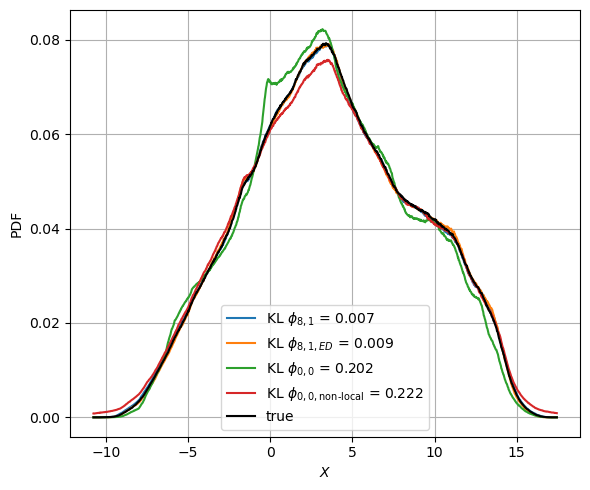

In [7]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
ax1.set(xlabel=r'$X$', ylabel='PDF')

for P_X, model_name in zip(P_Xs, [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    eps = 1.e-12
    ax1.plot(Xbins[1:], P_X, label=f'KL {model_name} = {round(np.sum(rel_entr(P_X_true, P_X + eps)), 3)}')
ax1.plot(Xbins[1:], P_X_true, label=f'true', c='black')

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid()

plt.tight_layout()

# Significant Weather Analysis

In [8]:
def get_X_weather(base_path, m, tau, sim_time=13, K=8):
    files = os.listdir(base_path)
    nruns=500

    X = np.zeros(shape=(nruns, sim_time*1000, K))
    for file in files:
        if (f'm={m}' in file) and (f'tau={tau}' in file): 
            seed = int(file.split('seed=')[1].split('_')[0])
            L96 = xr.open_dataset(base_path + file)
            X[seed] = L96.X.values
    return X

Xw_true = get_X_weather('weather_runs/NO_PARAMETRIZATION/', 0.001, 0.001, 7)
# X_ODE = get_X_weather('weather_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/', 0.001, 0.001, 7)
X_ODE = get_X_weather('weather_runs/ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0/', 0.001, 0.001, 7)
X_base = get_X_weather('weather_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/', 0.001, 0.001, 7)
X_nonlocal = get_X_weather('weather_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/', 0.001, 0.001, 7)
X_AE = get_X_weather('weather_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/', 0.001, 0.001, 7)

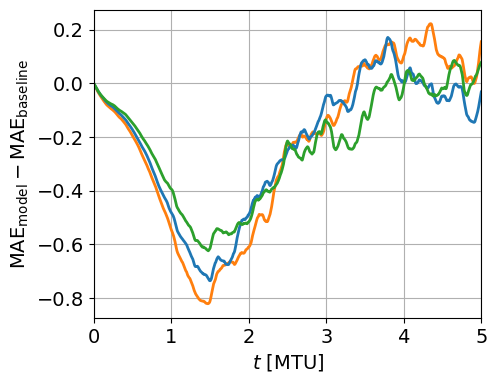

In [21]:
Xs = [X_base, X_AE, X_ODE, X_nonlocal]
model_names = ['autoencoder', 'linear ODE', 'baseline', 'non-local baseline']
colors=['tab:purple', 'tab:orange', 'tab:blue', 'tab:green']
# Xs = [X_base, X_nonlocal, X_ODE]
# model_names = [r'$\phi_{0,0,1}$', r'$\phi_{0,0,8}$', r'$\phi_{8,1,1,ODE}$']

def plot_MAE_weather(X_true, Xs, model_names, trunc_sims=None, fig=None, ax=None, colors=colors):
    if fig:
        pass
    else:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    if trunc_sims:
        Xs = [X[:trunc_sims] for X in Xs]
        X_true = X_true[:trunc_sims]

    t = np.arange(X_true.shape[1]) * .001 - 2
    MAE = np.sum(np.absolute(X_true - Xs[0]), axis=2) / 8
    mean_MAE_base = np.mean(MAE, axis=0)
    for X, model_name, color in zip(Xs[1:], model_names[1:], colors[1:]):
        MAE = np.sum(np.absolute(X_true - X), axis=2) / 8
        mean_MAE = np.mean(MAE, axis=0)
        std_MAE = np.std(MAE, axis=0)
        #ax.plot(t, mean_MAE, label=model_name)
        ax.plot(t, mean_MAE - mean_MAE_base, label=model_name, c=color)
        # ax.fill_between(t, mean_MAE-std_MAE, mean_MAE+std_MAE, alpha=0.2, color=color)
    
    ax.set(xlim=(0, 5.0), xlabel=r'$t$ [MTU]', ylabel=r'$\text{MAE}_\text{model} - \text{MAE}_\text{baseline}$')
    #ax.legend()
    ax.grid()

plot_MAE_weather(Xw_true, Xs, model_names)

(<Figure size 500x400 with 1 Axes>,
 <Axes: xlabel='$t$ [MTU]', ylabel='$\\text{MAE}_\\text{model} - \\text{MAE}_\\text{baseline}$'>)

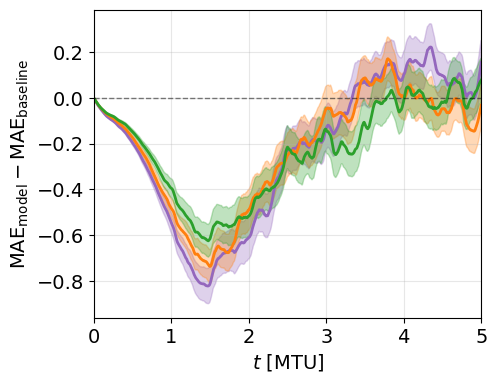

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_MAE_weather(X_true, Xs, model_names, trunc_sims=None, fig=None, ax=None, colors=None):
    if colors is None:
        colors = ['tab:blue', 'tab:purple', 'tab:orange', 'tab:green']
    
    if fig is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    
    if trunc_sims:
        Xs = [X[:trunc_sims] for X in Xs]
        X_true = X_true[:trunc_sims]

    n_sims = X_true.shape[0]
    t = np.arange(X_true.shape[1]) * 0.001 - 2
    
    # --- Compute baseline MAE (per simulation) ---
    MAE_base = np.sum(np.absolute(X_true - Xs[0]), axis=2) / 8  # Shape: (n_sims, n_time)
    mean_MAE_base = np.mean(MAE_base, axis=0)
    
    # --- Plot differences for each model ---
    for X, model_name, color in zip(Xs[1:], model_names[1:], colors[1:]):
        MAE = np.sum(np.absolute(X_true - X), axis=2) / 8
        
        # --- Compute difference PER SIMULATION (paired comparison) ---
        MAE_diff = MAE - MAE_base  # Shape: (n_sims, n_time)
        mean_diff = np.mean(MAE_diff, axis=0)
        std_diff = np.std(MAE_diff, axis=0)
        se_diff = std_diff / np.sqrt(n_sims)  # Standard error
        
        # --- Plot mean difference with uncertainty band ---
        ax.plot(t, mean_diff, label=model_name, c=color, linewidth=2)
        ax.fill_between(t, mean_diff - se_diff, mean_diff + se_diff, 
                        alpha=0.3, color=color, label=None)
    
    ax.set(xlim=(0, 5.0), xlabel=r'$t$ [MTU]', 
           ylabel=r'$\text{MAE}_\text{model} - \text{MAE}_\text{baseline}$')
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(alpha=0.3)
    
    return fig, ax

# Usage
plot_MAE_weather(Xw_true, Xs, model_names)

In [23]:
FS = 14
plt.rcParams.update({
    "font.size": FS,              # base font size
    "axes.labelsize": FS,         # x/y labels
    "xtick.labelsize": FS,        # x tick labels
    "ytick.labelsize": FS,        # y tick labels
    "legend.fontsize": FS,        # legend
    'axes.linewidth': 0.8,
    'lines.linewidth': 2.0
})


In [ ]:
plt.rcParams.keys()

/tmp/ipykernel_398702/2948821995.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


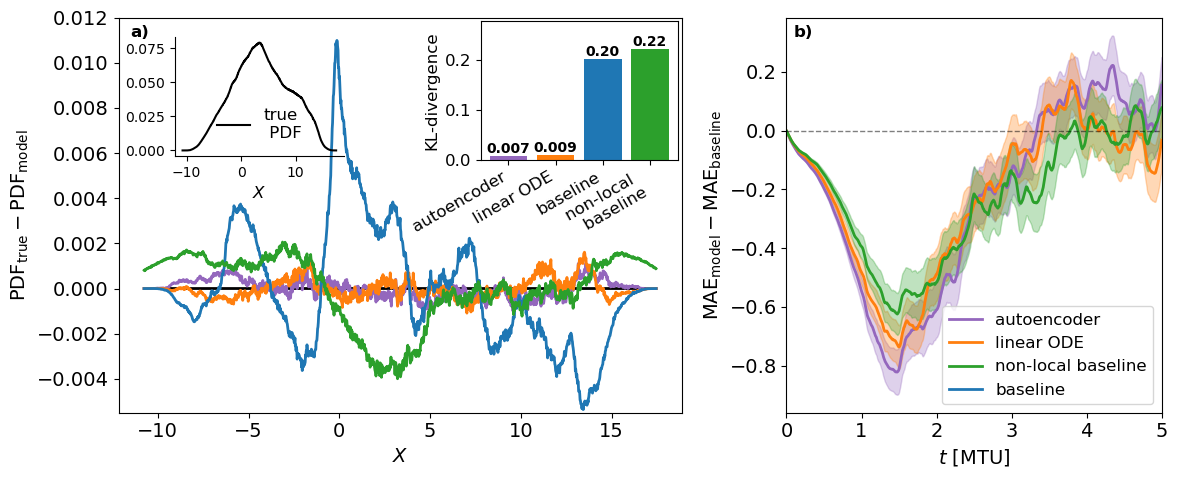

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import rel_entr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ----------------------
# Figure with 60/40 split
# ----------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [3, 2.0]}
)

# ----------------------
# Axis labels
# ----------------------
ax1.set(
    xlabel=r'$X$',
    ylabel=r'$\text{PDF}_{\text{true}} - \text{PDF}_{\text{model}}$'
)
# ----------------------
# True Distribution Inset (in ax1 - upper left with custom x-padding)
# ----------------------
ax_true = inset_axes(
    ax1,
    width="30%",
    height="30%",
    loc="upper left",
    borderpad=0,
    bbox_to_anchor=(0.10, -0.05, 1, 1),
    bbox_transform=ax1.transAxes
)

ax_true.plot(Xbins[1:], P_X_true, c='black', linewidth=1.5, label='true\n PDF', zorder=0)
ax_true.legend(loc='lower center', fontsize=12, frameon=False)
ax_true.set_xlabel(r'$X$', fontsize=12)
ax_true.tick_params(axis='both', labelsize=10)
ax_true.spines['top'].set_visible(False)
ax_true.spines['right'].set_visible(False)
ax_true.set_facecolor('none')
# ----------------------
# Compute KL + plot curves
# ----------------------
kl_values = []
eps = 1.e-12
model_names[-1] = 'non-local \n baseline'
for P_X, model_name, color in zip(P_Xs, model_names, colors):
    kl = np.sum(rel_entr(P_X_true, P_X + eps))
    kl_values.append(kl)

    ax1.plot(
        Xbins[1:],
        P_X - P_X_true,
        label=model_name,
        c=color
    )

# True reference line
ax1.plot(
    Xbins[1:],
    P_X_true - P_X_true,
    label='true',
    c='black',
    zorder=0
)

# ----------------------
# KL bar plot (inset in ax1 - upper right)
# ----------------------
ax_kl = inset_axes(
    ax1,
    width="35%",
    height="35%",
    loc="upper right",
    borderpad=0.2
)

# Create bars and store the container for labeling
bars = ax_kl.bar(model_names, kl_values, color=colors)

# Add value labels on top of each bar
for bar, kl_val in zip(bars, kl_values):
    height = bar.get_height()
    
    # Format value (adjust decimal places as needed)
    if kl_val < 0.01:
        label_text = f'{kl_val:.3f}'  # 3 decimals for small values
    else:
        label_text = f'{kl_val:.2f}'  # 2 decimals for larger values
    
    ax_kl.text(
        bar.get_x() + bar.get_width() / 2,  # x-position (center of bar)
        height,                              # y-position (top of bar)
        label_text,                          # text to display
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=10,                          # font size
        fontweight='bold'                   # make it stand out
    )

ax_kl.set_ylabel("KL-divergence", fontsize=12)
ax_kl.set_xticks(range(len(model_names)))
ax_kl.set_xticklabels(model_names, rotation=30, ha='right', fontsize=12)
ax_kl.tick_params(axis='both', labelsize=12)

# Optional: Add some space above bars for labels
ax_kl.set_ylim(0, max(kl_values) * 1.25)  # 25% extra space on top

# ----------------------
# MAE Weather Plot (ax2)
# ----------------------
plot_MAE_weather(Xw_true, Xs, ['baseline', 'autoencoder', 'linear ODE', 'non-local baseline'], None, fig, ax2)
ax2.grid()
ax2.plot([], [], label='baseline', color='tab:blue')  # Dummy scatter for legend
ax2.legend(loc='lower right', fontsize=12)

# ----------------------
# Subplot labels
# ----------------------
labels = ["a)", "b)"]

for ax, label in zip([ax1, ax2], labels):
    ax.text(
        0.02, 0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

ax1.set_ylim(-0.0055, 0.012)

# ----------------------
# Layout
# ----------------------
plt.tight_layout()
plt.savefig('L96_climate_weather.png', dpi=300, bbox_inches='tight')

In [5]:
model = torch.load('hyper_opt/latent_dims=6/m=0.001_tau=0.001_hyper_opt_w=1e-06_20260529134345.pkl', map_location='cpu', weights_only=False)
np.mean(model.nonlinear_predictability)

np.float32(0.9362991)

In [ ]:
L96 = xr.open_dataset('weather_runs/m=0.001_tau=0.001_t=500MTU_20250917165936.nc')
X, Y = L96.X.values, L96.Y.values
for i in range(50):
    initX = X[i*10_000]
    initY = Y[i*10_000]
    print(initY)

(2000.0, 10000.0)

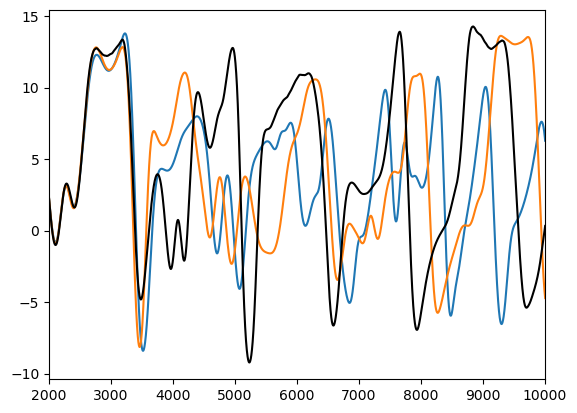

In [ ]:
seed=0
plt.plot(X_base[seed,:,0])
plt.plot(X_ODE[seed,:,0])
plt.plot(X_true[seed,:,0], color='black')
plt.xlim(2000, 10000)